### Context and structure of the notebook

This notebook applies machine learning to compare Ireland’s agricultural profile with other countries.

* Loads and checks the prepared FAOSTAT modelling dataset
* Applies scaling, PCA and clustering methods to identify countries agriculturally similar to Ireland
* Compares clustering results using internal validation metrics and interpretability checks
* Visualises shortlisted clustering solutions using t-SNE plots and dendrograms


In [1]:
# import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram

import matplotlib.pyplot as plt

from itertools import combinations
import math

import warnings
warnings.filterwarnings('ignore') # supress the warnings

### Load and preview the dataset

In [5]:
# read the cleaned csv file
df = pd.read_csv("country_cluster_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 49 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   country_code                              37 non-null     int64  
 1   country_name                              37 non-null     object 
 2   cereals_n_e_c_share_cropland              37 non-null     float64
 3   meat_of_goat_export_value_share           37 non-null     float64
 4   meat_of_goat_prod_t_per_pasture_ha        37 non-null     float64
 5   oats_share_cropland                       37 non-null     float64
 6   goats_export_value_share                  37 non-null     float64
 7   oats_yield_kg_per_ha                      37 non-null     float64
 8   swine_per_pigs_export_value_share         37 non-null     float64
 9   oats_total_export_value_share             37 non-null     float64
 10  chickens_export_value_share             

In [6]:
df.head()

,country_code,country_name,cereals_n_e_c_share_cropland,meat_of_goat_export_value_share,meat_of_goat_prod_t_per_pasture_ha,oats_share_cropland,goats_export_value_share,oats_yield_kg_per_ha,swine_per_pigs_export_value_share,oats_total_export_value_share,...,vegetables_primary_yield_kg_per_ha,wheat_yield_kg_per_ha,cattle_stocks_per_pasture_ha,sheep_stocks_per_pasture_ha,goats_stocks_per_pasture_ha,chickens_stocks_per_agri_land_ha,swine_stocks_per_agri_land_ha,meat_of_sheep_prod_t_per_pasture_ha,pasture_share_agri_land,dairy_products_total_export_value_share
0,32,Argentina,0.000623,8.366176e-06,0.100579,0.006409,8.600989e-08,2138.622222,2.706893e-06,0.000024,...,21248.477778,2975.033333,711.147315,185.659348,59.498062,980.885241,44.965460,0.647403,0.642700,0.020170
1,36,Australia,0.000000,4.228594e-03,0.084359,0.026762,1.246232e-04,1631.344444,6.231316e-07,0.003451,...,26408.855556,2320.988889,78.669116,210.390112,11.248691,283.131186,6.735344,2.187876,0.913046,0.042160
2,40,Austria,0.007498,2.484246e-07,0.552426,0.015415,6.655220e-05,3810.355556,2.601049e-04,0.000565,...,35278.400000,5626.611111,1528.341095,311.590072,72.072636,6392.821507,1044.809756,5.256979,0.470803,0.068638
3,56,Belgium,0.003205,8.021801e-06,0.731195,0.004173,6.513144e-06,5044.988889,3.346540e-03,0.000455,...,32930.488889,8607.244444,4998.419831,213.700911,106.978633,34974.440248,4469.953178,5.390249,0.351128,0.068601
4,76,Brazil,0.000000,1.566682e-07,0.204840,0.006914,3.016865e-09,2030.877778,4.332203e-05,0.000020,...,24857.800000,2667.322222,1278.549534,114.709228,65.149872,6176.974857,175.779599,0.568070,0.732121,0.001173


### Scaling

Scaling is required because the clustering models and principal component analysis (PCA) that we are going to use in this analysis are distance-based or variance-sensitive. 
- **K-Means** and **Hierarchical clustering** calculate similarity between countries using distances between feature values, while
- **PCA** is based on variance.

Without scaling, variables measured on larger numerical ranges, such as yields in kg/ha or animal stocks, would dominate variables expressed as shares or proportions, even if both are equally important agriculturally. 

Therefore, feature scaling is applied before clustering to ensure that each indicator contributed comparably to the distance calculations and dimensionality reduction.

#### Check features destributions/outliers/skewness

In [18]:
# define identifier columns (country_name, country_code)
id_cols = ["country_code", "country_name"]

# drop identifier columns
X = df.drop(columns=id_cols, errors="ignore")
# keep numeric features only
X = X.select_dtypes(include="number")

print("Countries:", X.shape[0])
print("Numeric features:", X.shape[1])
print("Missing values:", X.isna().sum().sum())

Countries: 37
Numeric features: 47
Missing values: 0


We checked descriptive statistics, IQR outliers, and measures of shape (skewness) of all numeric features in **Statistics notebook**.

Among 47 numeric features we have:
- 33 very highly skewed features (`abs(skewness) > 2`)
- 6 highly skewed features (`abs(skewness) between 1 and 2`)
- 41 features with IQR outliers
- 39 features that both highly skewed and have outliers
- 6 features with no IQR outliers and not strongly skewed

Most features are *not* normally distributed. The majority are strongly right-skewed and contain IQR-detected outliers.

In this agricultural context, skewness can be meaningful. For example, if one or two countries have extremely high sheep density, dairy production per pasture hectare, or potato export share, that is part of their agricultural profile. A log or power transformation would compress those extremes and could make genuinely distinctive countries look more similar than they really are.

#### The three scalers we should test:

1. `StandardScaler` removes the mean and scales each feature to unit variance. This is commonly used when variables are roughly symmetric or approximately normally distributed. In our dataset, only a small number of variables (6 out of 47) are normal-ish, so StandardScaler is included mainly as a baseline preprocessing method rather than as the expected best option. Scikit-learn also notes that StandardScaler can be influenced by outliers because it uses the mean and standard deviation. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

2. `MinMaxScaler` rescales each feature to a fixed range, usually 0 to 1, and is commonly used for skewed variables. Since many features in the dataset are skewed, it is reasonable to test it. However, MinMaxScaler does not remove skewness; it simply rescales the existing distribution into a common range. Scikit-learn describes it as scaling and translating each feature to a chosen range. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

3. `RobustScaler` removes the median and scales according to the interquartile range. This is suitable when features contain outliers because median and IQR are less affected by extreme values than mean and standard deviation. Since most features in this dataset have IQR-detected outliers, RobustScaler is especially relevant to test. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html

In [24]:
# Create a dictionary of chosen scalers
scalers = {
    "standard_scaler": StandardScaler(),
    "minmax_scaler": MinMaxScaler(),
    "robust_scaler": RobustScaler()
}

In [19]:
# Apply scalers and inspect scaled data
scaled_data = {}

# Loop through each of the scalers in scalers dictionary
for scaler_name, scaler in scalers.items():
    # fit the data = learn scaling parameters from the data
    X_scaled = scaler.fit_transform(X)

    # put scaled data frame into scaled_data dict with corresponding scaler_name as key
    scaled_data[scaler_name] = pd.DataFrame(
        X_scaled,
        columns=X.columns,
        index=df["country_name"])

# check data frame scaled with standard_scaler
scaled_data["standard_scaler"].head()

,cereals_n_e_c_share_cropland,meat_of_goat_export_value_share,meat_of_goat_prod_t_per_pasture_ha,oats_share_cropland,goats_export_value_share,oats_yield_kg_per_ha,swine_per_pigs_export_value_share,oats_total_export_value_share,chickens_export_value_share,meat_of_cattle_prod_t_per_pasture_ha,...,vegetables_primary_yield_kg_per_ha,wheat_yield_kg_per_ha,cattle_stocks_per_pasture_ha,sheep_stocks_per_pasture_ha,goats_stocks_per_pasture_ha,chickens_stocks_per_agri_land_ha,swine_stocks_per_agri_land_ha,meat_of_sheep_prod_t_per_pasture_ha,pasture_share_agri_land,dairy_products_total_export_value_share
country_name,,,,,,,,,,,,,,,,,,,,,
Argentina,-0.512578,-0.255748,-0.185945,-0.610957,-0.264697,-0.595603,-0.468505,-0.382401,-0.826134,-0.341997,...,-0.581075,-0.953256,-0.381732,-0.201159,-0.188901,-0.750418,-0.590259,-0.205874,0.915603,-0.638536
Australia,-0.674451,5.811297,-0.186026,0.197858,0.087327,-0.912841,-0.468690,0.040663,-0.798833,-0.384552,...,-0.056291,-1.258390,-0.451581,-0.200296,-0.191067,-0.817300,-0.617468,-0.200081,1.968237,-0.436394
Austria,1.272586,-0.267418,-0.183664,-0.253078,-0.076820,0.449856,-0.445668,-0.315646,-0.417415,-0.162771,...,0.845695,0.283794,-0.291483,-0.196766,-0.188337,-0.231665,0.121345,-0.188540,0.246291,-0.193000
Belgium,0.157753,-0.256243,-0.182762,-0.699812,-0.246530,1.221963,-0.171826,-0.329138,0.369067,0.317866,...,0.606925,1.674360,0.091743,-0.200181,-0.186769,2.507982,2.559067,-0.188039,-0.219682,-0.193339
Brazil,-0.674451,-0.267550,-0.185418,-0.590874,-0.264932,-0.662983,-0.464901,-0.382846,-0.514303,-0.333960,...,-0.214026,-1.096813,-0.319069,-0.203634,-0.188647,-0.252354,-0.497156,-0.206173,1.263778,-0.813163


In [23]:
# Quick check to confirm that the scalers actually changed the feature ranges
# We show each scaled data frame's mean, std, mian and max (from pd.describe finction)

# Loop through each scaled version of the dataset
# scaled_data is a dictionary where:
#   key   = scaler name, e.g. "standard_scaler"
#   value = scaled dataset as a DataFrame
for scaler_name, X_scaled_df in scaled_data.items():
    print("\n", scaler_name)
    print(X_scaled_df.describe().T[["mean", "std", "min", "max"]].head())


 standard_scaler
                                            mean       std       min       max
cereals_n_e_c_share_cropland        2.400482e-17  1.013794 -0.674451  3.166152
meat_of_goat_export_value_share     3.750753e-17  1.013794 -0.267775  5.811297
meat_of_goat_prod_t_per_pasture_ha -8.251658e-17  1.013794 -0.186452  5.973584
oats_share_cropland                -4.650934e-17  1.013794 -0.865631  4.423348
goats_export_value_share           -1.650332e-17  1.013794 -0.264940  5.859610

 minmax_scaler
                                        mean       std  min  max
cereals_n_e_c_share_cropland        0.175611  0.263967  0.0  1.0
meat_of_goat_export_value_share     0.044049  0.166768  0.0  1.0
meat_of_goat_prod_t_per_pasture_ha  0.030268  0.164576  0.0  1.0
oats_share_cropland                 0.163667  0.191680  0.0  1.0
goats_export_value_share            0.043259  0.165530  0.0  1.0

 robust_scaler
                                         mean         std       min  \
cereals_n_e_c_s

### Check PCA variance for each scaled version

We should not choose PCA blindly. First, check how many components are needed to retain useful variance:

In [26]:
# Create an empty list where we will store PCA summary results
pca_summary = []
# Create an empty dictionary to store PCA cumulative variance curves
pca_variance_curves = {}

# Loop through each scaled version of the dataset
# scaled_data is a dictionary where:
#   key   = scaler name, e.g. "standard_scaler"
#   value = scaled dataset as a DataFrame
for scaler_name, X_scaled_df in scaled_data.items():

    # Create a PCA object
    # We do not specify n_components here because we want PCA to calculate
    # all possible components first, so we can inspect explained variance
    pca = PCA()

    # Fit PCA to the scaled data = learn the principal components from this scaled dataset
    # We use fit(), not fit_transform(), because here we only need variance information, not the transformed PCA dataset yet
    pca.fit(X_scaled_df)

    # pca.explained_variance_ratio_ gives the proportion of variance explained by each principal component separately.
    # Example: PC1 explains 25%, PC2 explains 12%, PC3 explains 8%
    #
    # np.cumsum() converts this into cumulative variance:
    # PC1 = 25%, PC1 + PC2 = 37%, PC1 + PC2 + PC3 = 45%
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Store the cumulative variance curve for this scaler
    # (this will let us reuse it later for plotting without fitting PCA again)
    pca_variance_curves[scaler_name] = cumulative_variance

    # Check how many PCA components are needed to reach each variance threshold
    # For example:
    # 0.80 = how many components are needed to retain 80% of the original variance?
    # 0.90 = how many components are needed to retain 90%?
    # 0.95 = how many components are needed to retain 95%?
    for threshold in [0.80, 0.90, 0.95]:

        # cumulative_variance >= threshold returns True/False values
        # Example:
        # cumulative_variance = [0.35, 0.55, 0.72, 0.83, 0.91]
        # cumulative_variance >= 0.80 gives [False, False, False, True, True]
        #
        # np.argmax() returns the index of the first True value
        # Python indexing starts at 0, so we add +1 to get the actual number of components:
        n_components = np.argmax(cumulative_variance >= threshold) + 1

        # Save the result for this scaler and this variance threshold
        pca_summary.append({
            "scaler": scaler_name,
            "variance_threshold": threshold,
            "n_components": n_components,     # number of PCA components needed to reach this threshold
            "cumulative_variance": cumulative_variance[n_components - 1]     # actual cumulative variance retained by that number of components
        })

# Convert the list of dictionaries into a DataFrame
pca_summary_df = pd.DataFrame(pca_summary)
pca_summary_df

,scaler,variance_threshold,n_components,cumulative_variance
0,standard_scaler,0.80,9,0.825027
1,standard_scaler,0.90,13,0.912989
2,standard_scaler,0.95,16,0.953416
3,minmax_scaler,0.80,9,0.823556
4,minmax_scaler,0.90,13,0.913037
5,minmax_scaler,0.95,16,0.952799
6,robust_scaler,0.80,1,0.990449
7,robust_scaler,0.90,1,0.990449
8,robust_scaler,0.95,1,0.990449


Plot stored PCA cumulative variance curves:

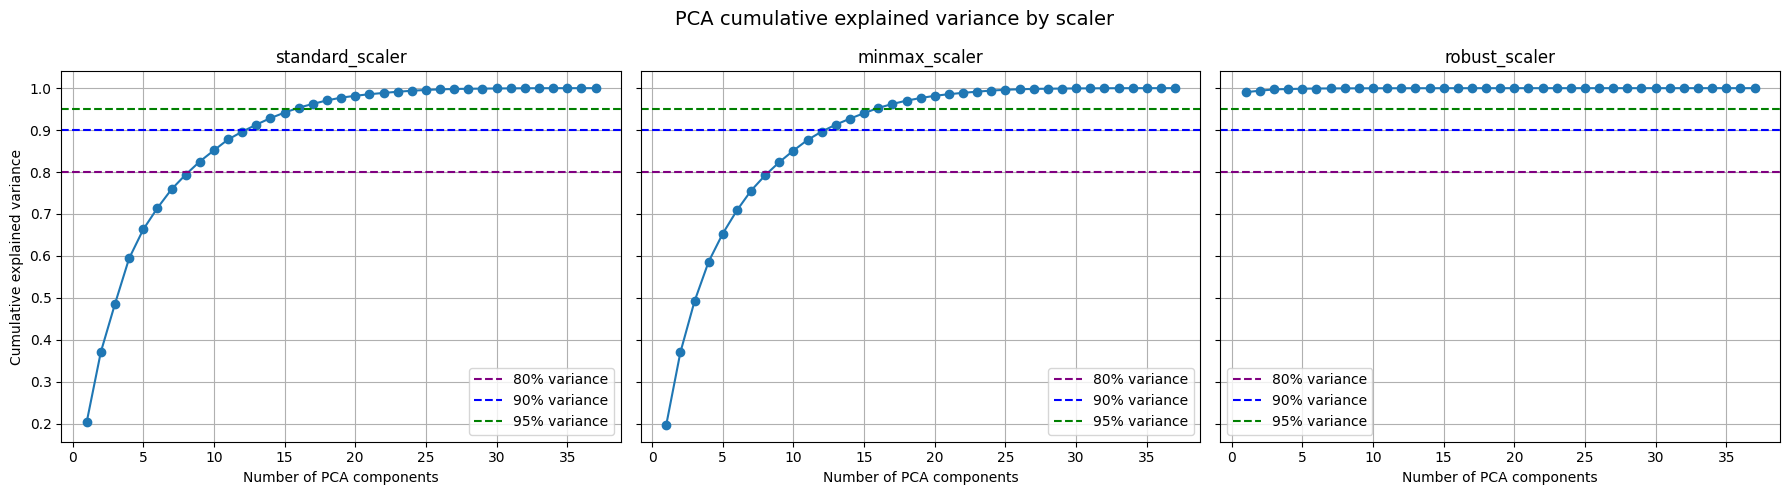

In [40]:
# Create one figure with 1 row and 3 columns for each of the scalers
# sharey=True means all three plots use the same y-axis scale:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), sharey=True)

# Loop through each stored PCA cumulative variance curve
# zip(axes, pca_variance_curves.items()) lets us loop through:
#   - one subplot axis at a time
#   - one scaler and its PCA variance curve at a time
for ax, (scaler_name, cumulative_variance) in zip(axes, pca_variance_curves.items()):

    # Plot cumulative explained variance against the number of PCA components
    # x-axis: 1, 2, 3, ..., total number of PCA components
    # y-axis: cumulative explained variance retained by those components
    ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")

    # add horizontal reference lines at 80%, 90% and 95% explained variance
    ax.axhline(0.80, linestyle="--", label="80% variance", color="purple")
    ax.axhline(0.90, linestyle="--", label="90% variance", color="blue")
    ax.axhline(0.95, linestyle="--", label="95% variance", color="green")
    ax.legend(loc="best")
    ax.set_xlabel("Number of PCA components")
    ax.set_title(scaler_name)
    ax.grid(True)

# add one shared y-axis label on the first subplot only
axes[0].set_ylabel("Cumulative explained variance")

# add one main title for the whole figure
fig.suptitle("PCA cumulative explained variance by scaler", fontsize=14)

plt.tight_layout()
plt.show()

The PCA cumulative variance plots show that the choice of scaler strongly affects the PCA structure. 

For `StandardScaler` and `MinMaxScaler`, explained variance accumulates gradually, with 13 components required to retain around 90% of the variance and 16 components required to retain around 95%. This suggests that the dataset is multidimensional and that reducing the data to only two principal components would lose a substantial amount of information.

The `RobustScaler` result is different: the first principal component explains almost all of the variance. This indicates that, after scaling by the median and interquartile range, the PCA structure may be dominated by a small number of extreme country profiles or highly distinctive features. Since these extremes may represent genuine agricultural specialisation, they are not removed, but this result means that PCA after RobustScaler should be interpreted carefully.

Therefore, PCA will be tested as an optional dimensionality reduction step rather than applied automatically. For final clustering, models will be compared both with PCA retaining 90% variance and without PCA for `StandardScaler` and `MinMaxScaler`, and without PCA for `RobustScaler` (because PCA 90% would reduce the data to only 1 component) using internal clustering metrics and cluster interpretability, especially the composition of Ireland’s cluster.

#### Helper function to prepare scaled/PCA data

In [41]:
def prepare_model_data(X, scaler, pca_option=None):
    """
    Scale the feature matrix and optionally apply PCA

    Parameters:
        X = pandas DataFrame
        scaler = the scaler to apply before clustering
        pca_option = controls whether PCA is applied after scaling:
            None: PCA is not applied
            float: PCA keeps enough components to retain that proportion of variance
            integer: PCA keeps exactly that number of components
    Returns:
        X_pca = numpy array
        pca_label : a readable label describing whether PCA was used
        n_components : number of features/components used for clustering
        variance_retained : proportion of variance retained by PCA (if PCA is not applied, this is set to np.nan)
    """

    # Fit the scaler to the full clustering dataset and transform it
    X_scaled = scaler.fit_transform(X)

    # If pca_option is None, skip PCA (the clustering model will use the full scaled feature space)
    if pca_option is None:

        # create a label to record that PCA was not used.
        pca_label = "no_pca"

        # number of modelling dimensions is the number of original numeric features
        n_components = X.shape[1]

        # PCA variance value doesn't exists here, so we use np.nan
        variance_retained = np.nan

        # return the scaled dataset and metadata
        return X_scaled, pca_label, n_components, variance_retained

    # If pca_option is not None, create a PCA object:
    # svd_solver="full" is used because variance-threshold PCA, such as n_components=0.90, requires the full solver in scikit-learn
    # random_state is included for reproducibility, although PCA itself is deterministic
    # when using the full solver.
    pca = PCA(
        n_components=pca_option,
        svd_solver="full",
        random_state=111)

    # Fit PCA to the scaled data and transform the scaled data into PCA space
    X_pca = pca.fit_transform(X_scaled)

    # Create a readable PCA label for the results table
    # If pca_option is a float, it represents a variance threshold
    if isinstance(pca_option, float):
        pca_label = f"pca_{int(pca_option * 100)}pct_variance"

    # If pca_option is an integer, it represents a fixed number of components
    else:
        pca_label = f"pca_{pca_option}_components"

    # Record the actual number of PCA components selected
    n_components = pca.n_components_

    # Record the total variance retained by the selected PCA components
    variance_retained = pca.explained_variance_ratio_.sum()

    # Return the PCA-transformed dataset and metadata
    return X_pca, pca_label, n_components, variance_retained

#### Define PCA options based on the PCA variance results

As discussed earlier, `StandardScaler` and `MinMaxScaler` have gradual cumulative variance curves, so PCA with 90% variance is reasonable to test for these. `RobustScaler` reaches almost all variance in the first component. This means PCA with a 90% threshold would reduce the data to almost one dimension. That may be too aggressive and may cause clustering to be dominated by one direction of variation, so RobustScaler is tested without PCA.

In [44]:
# Define which PCA options will be tested for each scaler
pca_options_by_scaler = {
    "standard_scaler": [None, 0.90],
    "minmax_scaler": [None, 0.90],
    "robust_scaler": [None]
}

### Cluster assessment

In addition to internal validation metrics (Silhouette score, Davies-Bouldin index, Calinski-Harabasz score), we will also consider **cluster size balance** when assessing the models. 

Some clustering results can produce high metric scores by isolating one or more outlier countries into singleton clusters while placing almost all remaining countries into one large cluster. Although such solutions are valid, they are less useful for this analysis because the aim is to identify meaningful groups of agriculturally similar countries. 

We will not exclude all singletons automatically at this stage. A solution with cluster sizes like `[1, 5, 7, 10, 14]` might still be worth inspecting, because the singleton could be a genuinely unique agricultural profile.

But solutions like `[1, 36]`, `[1, 1, 35]`, `[1, 1, 1, 34]` with 37 countries should definitely be filtered out or at least deprioritised.

Therefore, we flag the results as poorly interpretable when they contained at least one singleton cluster and one dominant cluster containing 75% or more of all countries.

In [114]:
def get_cluster_balance_diagnostics(labels, country_names, target_country="Ireland"):
    """
    Calculate cluster size, cluster balance, and target-country diagnostics for one clustering result

    Parameters:
        labels = cluster labels assigned by a clustering model
        country_names = country names in the same row order as the labels
        target_country = country of the main interest
    Returns:
        diagnostics : dictionary containing cluster size information and interpretability flags
    """

    # create a DataFrame linking each country to its assigned cluster label
    cluster_df = pd.DataFrame({
        "country_name": country_names,
        "cluster": labels
    })

    # count how many countries are assigned to each cluster
    cluster_sizes = cluster_df["cluster"].value_counts().sort_index()

    # count the total number of countries included in the clustering result
    n_countries = len(cluster_df)

    # count how many clusters contain only one country
    n_singleton_clusters = (cluster_sizes == 1).sum()

    # get the size of the smallest cluster
    min_cluster_size = cluster_sizes.min()

    # get the size of the largest cluster
    largest_cluster_size = cluster_sizes.max()

    # calculate the share of all countries that are placed in the largest cluster
    largest_cluster_share = largest_cluster_size / n_countries

    # calculate the ratio between the largest and smallest cluster
    # (a very high ratio means the clustering solution is highly imbalanced)
    cluster_size_ratio = largest_cluster_size / min_cluster_size

    # flag whether the model produced at least one singleton cluster
    has_singleton_cluster = n_singleton_clusters > 0

    # flag whether one cluster contains most (>=75%) countries
    is_dominant_cluster_solution = largest_cluster_share >= 0.75

    # flag the specific pattern we want to avoid: one or more singleton clusters plus one huge remaining cluster
    is_singleton_dominated_solution = (has_singleton_cluster and is_dominant_cluster_solution)

    # store the actual cluster sizes as a readable string separated by commas
    cluster_sizes_text = ", ".join(str(size) for size in sorted(cluster_sizes.tolist()))

    # create a dictionary of cluster members
    cluster_members_dict = (
        cluster_df
        .sort_values(["cluster", "country_name"])
        .groupby("cluster")["country_name"]
        .apply(lambda countries: ", ".join(countries))
        .to_dict())

    # convert cluster members into one compact text field separated by "|"
    cluster_members_text = " | ".join(f"Cluster {cluster}: {members}" 
                                      for cluster, members in cluster_members_dict.items())

    # find the cluster label assigned to the target country
    target_cluster = cluster_df.loc[cluster_df["country_name"] == target_country, "cluster"].iloc[0]

    # select all countries in the same cluster as the target country
    target_cluster_members = cluster_df.loc[cluster_df["cluster"] == target_cluster, "country_name"].sort_values().tolist()

    # count how many countries are in the target country's cluster
    target_cluster_size = len(target_cluster_members)

    # flag whether target country is alone in its cluster
    target_is_singleton = target_cluster_size == 1

    # store target country's cluster members as a readable string
    target_cluster_members_text = ", ".join(target_cluster_members)

    # return all diagnostics as a dictionary
    return {
        "cluster_sizes": cluster_sizes_text,
        "cluster_members": cluster_members_text,
        "n_singleton_clusters": n_singleton_clusters,
        "min_cluster_size": min_cluster_size,
        "largest_cluster_size": largest_cluster_size,
        "largest_cluster_share": largest_cluster_share,
        "cluster_size_ratio": cluster_size_ratio,
        "has_singleton_cluster": has_singleton_cluster,
        "is_dominant_cluster_solution": is_dominant_cluster_solution,
        "is_singleton_dominated_solution": is_singleton_dominated_solution,
        # "ireland_cluster": target_cluster,
        "ireland_cluster_size": target_cluster_size,
        "ireland_is_singleton": target_is_singleton,
        "ireland_cluster_members": target_cluster_members_text
    }

### Grid-style clustering search 

For:
   - K-Means
   - Agglomerative clustering

In [129]:
# Create a list to store the results from every model combination
results = []

# create a dictionary to store reusable model artifacts (labels, X_model, ...)
run_artifacts = {}

# create a list for country-level cluster assignments
all_label_rows = []

In [130]:
# Helper function to store every clustering run
# to avoid repeating the same storage logic for K-Means and Agglomerative clustering
def record_clustering_result(results, run_artifacts, all_label_rows, model_object, model_name, scaler_name, pca_label, n_components,
                             variance_retained, k, linkage, X_model, labels, inertia, df, target_country="Ireland"):
    """
    Store the results of one clustering run:
        1. Model-level metrics, scaler, PCA option, k, cluster sizes, Ireland's cluster, etc. to the results list
        2. Model labels, transformed modelling data, and fitted model object in run_artifacts using a unique run_id
        3. Country-level assignments to all_label_rows.

    Parameters:
        results = list that stores model-level result dictionaries
        run_artifacts = dictionary that stores reusable outputs such as labels and X_model
        all_label_rows = list that stores country-level cluster assignments
        model_object = fitted sklearn clustering object
        model_name = name of clustering algorithm ("kmeans"/"agglomerative")
        scaler_name = name of scaler used before clustering
        pca_label = label describing whether PCA was used
        n_components = number of features/components used by the clustering model
        variance_retained : variance retained by PCA (np.nan if PCA was not used)
        k = number of clusters
        linkage = linkage method for Agglomerative clustering (None for K-Means)
        X_model = final data matrix used for clustering
        labels = cluster labels assigned to countries
        inertia = K-Means inertia (np.nan for Agglomerative clustering)
        df = original country-level DataFrame containing country_code and country_name
        target_country = country of main interest (default is Ireland)
    """

    # convert linkage to a readable string for run_id (k-Means does not use linkage, so we record it as "none")
    linkage_label = "none" if linkage is None else linkage

    # create a unique ID for this clustering run (e.g. kmeans_standard_scaler_pca_90pct_variance_k6_none)
    run_id = (
        f"{model_name}_"
        f"{scaler_name}_"
        f"{pca_label}_"
        f"k{k}_"
        f"{linkage_label}"
    )

    # calculate internal clustering validation metrics:
    # 1. Silhouette score (higher is better):
    #      measures how similar countries are to their own cluster compared with other clusters
    # 2. Davies-Bouldin index (lower is better):
    #      measures average similarity between clusters, where lower values indicate better separation
    # 3. Calinski-Harabasz score (higher is better):
    #      compares between-cluster dispersion with within-cluster dispersion
    silhouette = silhouette_score(X_model, labels)
    davies_bouldin = davies_bouldin_score(X_model, labels)
    calinski_harabasz = calinski_harabasz_score(X_model, labels)

    # calculate cluster size and balance diagnostics
    balance = get_cluster_balance_diagnostics(labels=labels, country_names=df["country_name"], target_country=target_country)

    # store the model-level result (this is the row that will appear in results_df)
    results.append({
        "run_id": run_id,
        "model": model_name,
        "scaler": scaler_name,
        "pca": pca_label,
        "n_components": n_components,
        "variance_retained": variance_retained,
        "k": k,
        "linkage": linkage,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "inertia": inertia,
        # unpack every key-value pair from the balance dictionary and insert them into this results dictionary
        **balance
    })

    # store reusable artifacts for this clustering run
    run_artifacts[run_id] = {
        "run_id": run_id,
        "model": model_object,
        "model_name": model_name,
        "scaler_name": scaler_name,
        "pca_label": pca_label,
        "n_components": n_components,
        "variance_retained": variance_retained,
        "k": k,
        "linkage": linkage,
        "X_model": X_model,
        "labels": labels
    }

    # store country-level cluster assignments for this run
    for country_code, country_name, cluster_label in zip(df["country_code"], df["country_name"], labels):
        all_label_rows.append({
            "run_id": run_id,
            "model": model_name,
            "scaler": scaler_name,
            "pca": pca_label,
            "k": k,
            "linkage": linkage,
            "country_code": country_code,
            "country_name": country_name,
            "cluster": cluster_label
        })

In [131]:
# Define the range of cluster numbers to test
# k=1 is not included because clustering validation metrics such as silhouette score require at least 2 clusters
# The upper limit is kept moderate because we only have 37 countries
# (testing too many clusters would produce very small clusters that are harder to interpret)
k_values = range(2, 20)

# Loop through each scaler
for scaler_name, scaler in scalers.items():

    # get the PCA options assigned to this specific scaler
    scaler_pca_options = pca_options_by_scaler[scaler_name]

    # Loop through the PCA options for this scaler
    for pca_option in scaler_pca_options:

        # Prepare the modelling dataset with the function we created earlier
        # this function applies the selected scaler, optionally applies PCA, and returns the final data matrix for clustering
        X_model, pca_label, n_components, variance_retained = prepare_model_data(X=X, scaler=scaler, pca_option=pca_option)

        # Loop through each candidate number of clusters
        for k in k_values:

            ### K-Means clustering ###

            # create the K-Means model
            # n_init=100 means K-Means will run 20 times with different initial centroids and keep the best solution
            kmeans = KMeans(n_clusters=k, n_init=100, random_state=111)

            # fit K-Means and return the cluster label assigned to each country
            kmeans_labels = kmeans.fit_predict(X_model)

            # store the K-Means result, labels, X_model, metrics, and diagnostics
            record_clustering_result(results=results, run_artifacts=run_artifacts, all_label_rows=all_label_rows, model_object=kmeans, 
                                     model_name="kmeans", scaler_name=scaler_name, pca_label=pca_label, n_components=n_components, 
                                     variance_retained=variance_retained, k=k, linkage=None, X_model=X_model, labels=kmeans_labels, 
                                     inertia=kmeans.inertia_, df=df, target_country="Ireland")

            
            ### Agglomerative hierarchical clustering ###

            # Test several linkage methods:
            #    ward: minimises within-cluster variance. Often works well with compact, spherical-ish clusters
            #    complete: uses the maximum distance between points in two clusters. Tends to create compact clusters and is sensitive to outliers
            #    average: uses the average distance between points in two clusters. Often less strict than complete linkage
            for linkage in ["ward", "complete", "average"]:

                # create the agglomerative clustering model
                agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)

                # fit the hierarchical model and return cluster labels
                agg_labels = agg.fit_predict(X_model)

                # Store the Agglomerative result, labels, X_model, metrics, and diagnostics.
                record_clustering_result(results=results, run_artifacts=run_artifacts, all_label_rows=all_label_rows, model_object=agg, 
                                         model_name="agglomerative", scaler_name=scaler_name, pca_label=pca_label, n_components=n_components, 
                                         variance_retained=variance_retained, k=k, linkage=linkage, X_model=X_model, labels=agg_labels, 
                                         inertia=np.nan, df=df, target_country="Ireland")

# Convert the list of results into a DataFrame
results_df = pd.DataFrame(results)
# Convert the list of country-level labels into a DataFrame
all_cluster_assignments_df = pd.DataFrame(all_label_rows)

In [132]:
results_df

,run_id,model,scaler,pca,n_components,variance_retained,k,linkage,silhouette,davies_bouldin,...,min_cluster_size,largest_cluster_size,largest_cluster_share,cluster_size_ratio,has_singleton_cluster,is_dominant_cluster_solution,is_singleton_dominated_solution,ireland_cluster_size,ireland_is_singleton,ireland_cluster_members
0,kmeans_standard_scaler_no_pca_k2_none,kmeans,standard_scaler,no_pca,47,NaN,2,None,0.529348,0.329682,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
1,agglomerative_standard_scaler_no_pca_k2_ward,agglomerative,standard_scaler,no_pca,47,NaN,2,ward,0.529348,0.329682,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
2,agglomerative_standard_scaler_no_pca_k2_complete,agglomerative,standard_scaler,no_pca,47,NaN,2,complete,0.529348,0.329682,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
3,agglomerative_standard_scaler_no_pca_k2_average,agglomerative,standard_scaler,no_pca,47,NaN,2,average,0.529348,0.329682,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
4,kmeans_standard_scaler_no_pca_k3_none,kmeans,standard_scaler,no_pca,47,NaN,3,None,0.356566,1.260428,...,1,32,0.864865,32.0,True,True,True,32,False,"Argentina, Australia, Austria, Brazil, Bulgari..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,agglomerative_robust_scaler_no_pca_k18_average,agglomerative,robust_scaler,no_pca,47,NaN,18,average,0.114360,0.437153,...,1,14,0.378378,14.0,True,False,False,1,True,Ireland
356,kmeans_robust_scaler_no_pca_k19_none,kmeans,robust_scaler,no_pca,47,NaN,19,None,0.080010,0.547008,...,1,7,0.189189,7.0,True,False,False,1,True,Ireland
357,agglomerative_robust_scaler_no_pca_k19_ward,agglomerative,robust_scaler,no_pca,47,NaN,19,ward,0.079673,0.542326,...,1,8,0.216216,8.0,True,False,False,1,True,Ireland
358,agglomerative_robust_scaler_no_pca_k19_complete,agglomerative,robust_scaler,no_pca,47,NaN,19,complete,0.089015,0.518750,...,1,10,0.270270,10.0,True,False,False,1,True,Ireland


#### Rank model results

- Sort all models by **Silhouette score**, from highest to lowest.

This gives an initial view of which models produced the most separated clusters. However, we can see that highest scored results have those unbalanced clusters with multiple singletone clusters and one big cluster with remaining countries:

In [133]:
results_df.sort_values(by="silhouette", ascending=False).head(20)

,run_id,model,scaler,pca,n_components,variance_retained,k,linkage,silhouette,davies_bouldin,...,min_cluster_size,largest_cluster_size,largest_cluster_share,cluster_size_ratio,has_singleton_cluster,is_dominant_cluster_solution,is_singleton_dominated_solution,ireland_cluster_size,ireland_is_singleton,ireland_cluster_members
290,agglomerative_robust_scaler_no_pca_k2_complete,agglomerative,robust_scaler,no_pca,47,NaN,2,complete,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
291,agglomerative_robust_scaler_no_pca_k2_average,agglomerative,robust_scaler,no_pca,47,NaN,2,average,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
288,kmeans_robust_scaler_no_pca_k2_none,kmeans,robust_scaler,no_pca,47,NaN,2,None,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
289,agglomerative_robust_scaler_no_pca_k2_ward,agglomerative,robust_scaler,no_pca,47,NaN,2,ward,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
292,kmeans_robust_scaler_no_pca_k3_none,kmeans,robust_scaler,no_pca,47,NaN,3,None,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
293,agglomerative_robust_scaler_no_pca_k3_ward,agglomerative,robust_scaler,no_pca,47,NaN,3,ward,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
294,agglomerative_robust_scaler_no_pca_k3_complete,agglomerative,robust_scaler,no_pca,47,NaN,3,complete,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
295,agglomerative_robust_scaler_no_pca_k3_average,agglomerative,robust_scaler,no_pca,47,NaN,3,average,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
300,kmeans_robust_scaler_no_pca_k5_none,kmeans,robust_scaler,no_pca,47,NaN,5,None,0.693454,0.104486,...,1,33,0.891892,33.0,True,True,True,33,False,"Argentina, Austria, Belgium, Brazil, Bulgaria,..."
302,agglomerative_robust_scaler_no_pca_k5_complete,agglomerative,robust_scaler,no_pca,47,NaN,5,complete,0.693454,0.104486,...,1,33,0.891892,33.0,True,True,True,33,False,"Argentina, Austria, Belgium, Brazil, Bulgaria,..."


- Sort all models by **Davies-Bouldin index**, from lowest to highest.

Lower Davies-Bouldin values indicate better-separated and more compact clusters. This provides another view of model quality, but again, we see that the "best" clustering results have highly unbalansed clusters.

In [134]:
results_df.sort_values(by="davies_bouldin", ascending=True).head(20)

,run_id,model,scaler,pca,n_components,variance_retained,k,linkage,silhouette,davies_bouldin,...,min_cluster_size,largest_cluster_size,largest_cluster_share,cluster_size_ratio,has_singleton_cluster,is_dominant_cluster_solution,is_singleton_dominated_solution,ireland_cluster_size,ireland_is_singleton,ireland_cluster_members
288,kmeans_robust_scaler_no_pca_k2_none,kmeans,robust_scaler,no_pca,47,NaN,2,None,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
291,agglomerative_robust_scaler_no_pca_k2_average,agglomerative,robust_scaler,no_pca,47,NaN,2,average,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
290,agglomerative_robust_scaler_no_pca_k2_complete,agglomerative,robust_scaler,no_pca,47,NaN,2,complete,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
289,agglomerative_robust_scaler_no_pca_k2_ward,agglomerative,robust_scaler,no_pca,47,NaN,2,ward,0.951755,0.013903,...,1,36,0.972973,36.0,True,True,True,36,False,"Argentina, Australia, Austria, Belgium, Brazil..."
293,agglomerative_robust_scaler_no_pca_k3_ward,agglomerative,robust_scaler,no_pca,47,NaN,3,ward,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
292,kmeans_robust_scaler_no_pca_k3_none,kmeans,robust_scaler,no_pca,47,NaN,3,None,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
294,agglomerative_robust_scaler_no_pca_k3_complete,agglomerative,robust_scaler,no_pca,47,NaN,3,complete,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
295,agglomerative_robust_scaler_no_pca_k3_average,agglomerative,robust_scaler,no_pca,47,NaN,3,average,0.782408,0.080992,...,1,35,0.945946,35.0,True,True,True,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
301,agglomerative_robust_scaler_no_pca_k5_ward,agglomerative,robust_scaler,no_pca,47,NaN,5,ward,0.693454,0.104486,...,1,33,0.891892,33.0,True,True,True,33,False,"Argentina, Austria, Belgium, Brazil, Bulgaria,..."
302,agglomerative_robust_scaler_no_pca_k5_complete,agglomerative,robust_scaler,no_pca,47,NaN,5,complete,0.693454,0.104486,...,1,33,0.891892,33.0,True,True,True,33,False,"Argentina, Austria, Belgium, Brazil, Bulgaria,..."


So, we will create a filtered version of the results table.

We exclude clustering solutions that are:
1. singleton-dominated solutions, like `[1, 36]`, `[1, 1, 35]`, etc.
2. solutions where Ireland itself is a singleton

These solutions are not useful for our research aim because they mainly isolate outliers while grouping almost all other countries together.

In [135]:
interpretable_results = results_df[
    (results_df["is_singleton_dominated_solution"] == False) &
    (results_df["ireland_is_singleton"] == False)
].copy()

# display the top interpretable results by Silhouette and Davies-Bouldin score
interpretable_results.sort_values(by=["silhouette", "davies_bouldin"], ascending=[False, True]).head(20)

,run_id,model,scaler,pca,n_components,variance_retained,k,linkage,silhouette,davies_bouldin,...,min_cluster_size,largest_cluster_size,largest_cluster_share,cluster_size_ratio,has_singleton_cluster,is_dominant_cluster_solution,is_singleton_dominated_solution,ireland_cluster_size,ireland_is_singleton,ireland_cluster_members
218,agglomerative_minmax_scaler_pca_90pct_variance...,agglomerative,minmax_scaler,pca_90pct_variance,13,0.913037,2,complete,0.429426,1.232642,...,2,35,0.945946,17.50,False,True,False,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
312,kmeans_robust_scaler_no_pca_k8_none,kmeans,robust_scaler,no_pca,47,NaN,8,None,0.426256,0.425370,...,1,27,0.729730,27.00,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."
313,agglomerative_robust_scaler_no_pca_k8_ward,agglomerative,robust_scaler,no_pca,47,NaN,8,ward,0.426256,0.425370,...,1,27,0.729730,27.00,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."
316,kmeans_robust_scaler_no_pca_k9_none,kmeans,robust_scaler,no_pca,47,NaN,9,None,0.418903,0.332965,...,1,27,0.729730,27.00,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."
317,agglomerative_robust_scaler_no_pca_k9_ward,agglomerative,robust_scaler,no_pca,47,NaN,9,ward,0.418903,0.332965,...,1,27,0.729730,27.00,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."
146,agglomerative_minmax_scaler_no_pca_k2_complete,agglomerative,minmax_scaler,no_pca,47,NaN,2,complete,0.397336,1.270684,...,2,35,0.945946,17.50,False,True,False,35,False,"Argentina, Australia, Austria, Belgium, Brazil..."
323,agglomerative_robust_scaler_no_pca_k10_average,agglomerative,robust_scaler,no_pca,47,NaN,10,average,0.388730,0.244753,...,1,27,0.729730,27.00,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."
327,agglomerative_robust_scaler_no_pca_k11_average,agglomerative,robust_scaler,no_pca,47,NaN,11,average,0.371798,0.243075,...,1,26,0.702703,26.00,True,False,False,26,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."
324,kmeans_robust_scaler_no_pca_k11_none,kmeans,robust_scaler,no_pca,47,NaN,11,None,0.355571,0.391704,...,1,25,0.675676,25.00,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."
325,agglomerative_robust_scaler_no_pca_k11_ward,agglomerative,robust_scaler,no_pca,47,NaN,11,ward,0.355571,0.391704,...,1,25,0.675676,25.00,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ..."


In [136]:
interpretable_results.shape

(103, 25)

#### Combined ranking table

We will calculate a simple average rank across the three validation metrics.

Lower average rank means the model performed better overall across metrics. This is not a perfect model-selection rule, but it is useful for summarising several metrics in one table.

In [137]:
# Make a copy of the interpretable results so we can add ranking columns
ranked_results = interpretable_results.copy()

# rank silhouette score: higher silhouette is better, so ascending=False
ranked_results["silhouette_rank"] = ranked_results["silhouette"].rank(ascending=False, method="min")

# rank Davies-Bouldin index: lower Davies-Bouldin is better, so ascending=True
ranked_results["davies_bouldin_rank"] = ranked_results["davies_bouldin"].rank(ascending=True, method="min")

# rank Calinski-Harabasz score: higher Calinski-Harabasz is better, so ascending=False
ranked_results["calinski_harabasz_rank"] = ranked_results["calinski_harabasz"].rank(ascending=False, method="min")

# Calculate average rank across the three validation metrics
ranked_results["average_metric_rank"] = ranked_results[["silhouette_rank", "davies_bouldin_rank", "calinski_harabasz_rank"]].mean(axis=1)
# ranked_results["average_metric_rank"] = ranked_results[["silhouette_rank", "davies_bouldin_rank"]].mean(axis=1)

# Sort by average metric rank
# we keep cluster size columns visible because model selection should consider
# not only metric scores but also whether the resulting clusters are interpretable
ranked_results.sort_values(
    by=["average_metric_rank", "has_singleton_cluster"],
    ascending=[True, True]
).head(20)

,run_id,model,scaler,pca,n_components,variance_retained,k,linkage,silhouette,davies_bouldin,...,has_singleton_cluster,is_dominant_cluster_solution,is_singleton_dominated_solution,ireland_cluster_size,ireland_is_singleton,ireland_cluster_members,silhouette_rank,davies_bouldin_rank,calinski_harabasz_rank,average_metric_rank
327,agglomerative_robust_scaler_no_pca_k11_average,agglomerative,robust_scaler,no_pca,47,NaN,11,average,0.371798,0.243075,...,True,False,False,26,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",8.0,2.0,27.0,12.333333
323,agglomerative_robust_scaler_no_pca_k10_average,agglomerative,robust_scaler,no_pca,47,NaN,10,average,0.388730,0.244753,...,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",7.0,3.0,32.0,14.000000
329,agglomerative_robust_scaler_no_pca_k12_ward,agglomerative,robust_scaler,no_pca,47,NaN,12,ward,0.308676,0.250205,...,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",18.0,4.0,21.0,14.333333
330,agglomerative_robust_scaler_no_pca_k12_complete,agglomerative,robust_scaler,no_pca,47,NaN,12,complete,0.308676,0.250205,...,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",18.0,4.0,21.0,14.333333
331,agglomerative_robust_scaler_no_pca_k12_average,agglomerative,robust_scaler,no_pca,47,NaN,12,average,0.308676,0.250205,...,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",18.0,4.0,21.0,14.333333
317,agglomerative_robust_scaler_no_pca_k9_ward,agglomerative,robust_scaler,no_pca,47,NaN,9,ward,0.418903,0.332965,...,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",4.0,8.0,33.0,15.000000
316,kmeans_robust_scaler_no_pca_k9_none,kmeans,robust_scaler,no_pca,47,NaN,9,None,0.418903,0.332965,...,True,False,False,27,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",4.0,8.0,34.0,15.333333
324,kmeans_robust_scaler_no_pca_k11_none,kmeans,robust_scaler,no_pca,47,NaN,11,None,0.355571,0.391704,...,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",9.0,13.0,24.0,15.333333
325,agglomerative_robust_scaler_no_pca_k11_ward,agglomerative,robust_scaler,no_pca,47,NaN,11,ward,0.355571,0.391704,...,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",9.0,13.0,24.0,15.333333
326,agglomerative_robust_scaler_no_pca_k11_complete,agglomerative,robust_scaler,no_pca,47,NaN,11,complete,0.355571,0.391704,...,True,False,False,25,False,"Argentina, Austria, Brazil, Bulgaria, Canada, ...",9.0,13.0,24.0,15.333333


In [138]:
ranked_results.shape

(103, 29)

In [123]:
# ranked_results.to_csv("ranked_results.csv")

These results suggest that the models with the best internal validation metrics are not necessarily the most useful models for the research question.

For this project, we are not just trying to maximise Silhouette / minimise Davies-Bouldin. We are trying to find **meaningful groups of agriculturally similar countries**, especially countries similar to Ireland.

The top metric results are mostly `robust_scaler + no_pca + high k`, but the cluster structures are often like `[1, 1, 1, 1, 1, 1, 1, 3, 27]` or `[1, 1, 1, 1, 1, 2, 3, 27]`. This means the model is creating many tiny clusters and one large cluster. Ireland is often inside the large cluster of around 25–27 countries, or sometimes only with the UK.

#### Why are high-k RobustScaler models ranking so well?

Because internal clustering metrics can reward outlier separation.

For example, if a few countries are agriculturally very unusual, the model can improve Silhouette or Davies-Bouldin by placing those countries into tiny or singleton clusters. Then the remaining countries form one large "general" cluster. Mathematically, that can look good. Interpretively, it is weak because Ireland + 25 other countries does not give us a clear "Ireland-like" group. And Ireland + UK only although completely valid, but may prevent us from exploring beyond the immediate nearest neighbor.

### K-Means elbow plots

This is only for K-Means because inertia is specific to K-Means clustering.

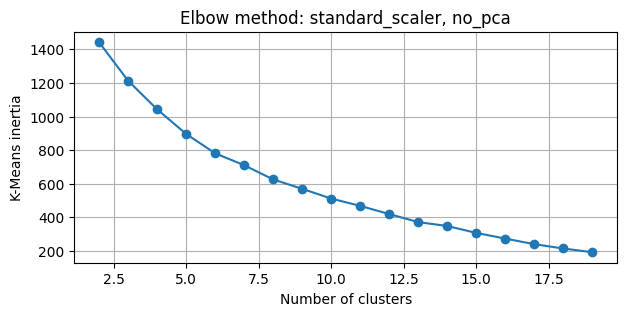

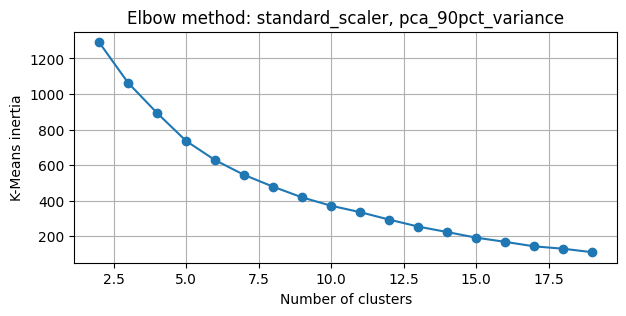

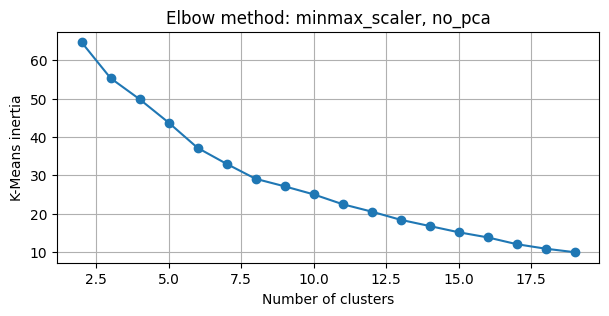

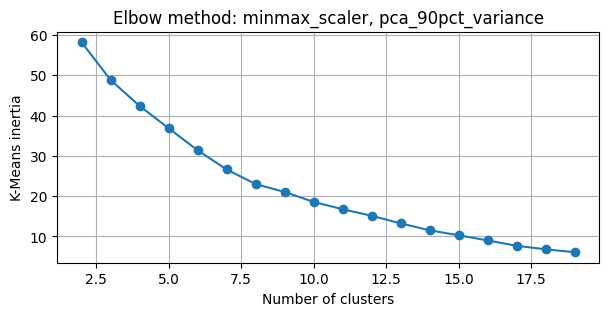

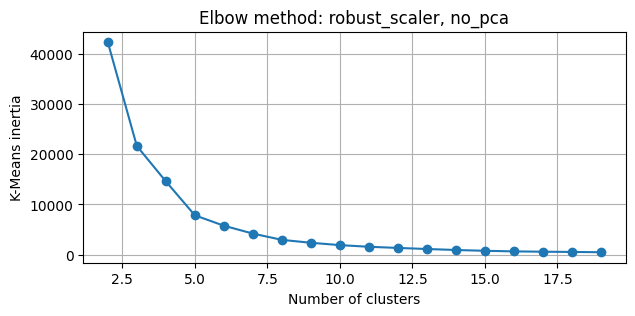

In [139]:
# Create a filtered DataFrame containing only K-Means results
kmeans_results = results_df[results_df["model"] == "kmeans"]

# Get each unique scaler/PCA combination used in K-Means
kmeans_setups = kmeans_results[["scaler", "pca"]].drop_duplicates()

# Create one elbow plot for each scaler/PCA setup
for _, setup in kmeans_setups.iterrows():

    # extract the scaler name and PCA label for this setup
    scaler_name = setup["scaler"]
    pca_label = setup["pca"]

    # select only rows matching this scaler and PCA setup
    subset = kmeans_results[
        (kmeans_results["scaler"] == scaler_name) &
        (kmeans_results["pca"] == pca_label)
    ]

    # sort by k so the elbow line is plotted in the correct order
    subset = subset.sort_values("k")

    # Create the elbow plot
    plt.figure(figsize=(7, 3))

    # Plot inertia against the number of clusters.
    #
    # Inertia measures within-cluster sum of squared distances
    # Lower inertia means countries are closer to their assigned cluster centroids
    # However, inertia always decreases as k increases, so we look for an "elbow" where improvement begins to slow down
    plt.plot(subset["k"], subset["inertia"], marker="o")

    plt.xlabel("Number of clusters")
    plt.ylabel("K-Means inertia")
    plt.title(f"Elbow method: {scaler_name}, {pca_label}")   # add a title describing the preprocessing setup
    plt.grid(True)                                           # add a grid for readability
    plt.show()

1. For `standard_scaler, no_pca` curve decreases quite smoothly. There is no one very sharp elbow. After around 5–7 clusters, inertia still decreases, but the improvement becomes more gradual. k around 5 or 6 may be reasonable.
2. `standard_scaler, pca_90pct_variance`: again, no sharp break. PCA reduced some dimensionality, but it did not produce a very obvious optimal number of clusters.
3. `minmax_scaler, no_pca` curve also decreases gradually. The decrease becomes slightly less steep after 6-8 clusters, but again there is no very clear elbow.
4. `minmax_scaler, pca_90pct_variance` plot is almost the same story as the previous one, suggesting that PCA did not radically change the K-Means inertia structure.
5. `robust_scaler, no_pca` is the only plot with a much clearer elbow. There is a very large drop from k=2 to k=5. After k=5 the curve starts flattening much more.

Overall, the elbow method did not identify a single clear optimal value of k across all preprocessing methods. For StandardScaler and MinMaxScaler, both with and without PCA, inertia decreased gradually, with possible weak elbows around k=5–8. RobustScaler without PCA showed the clearest elbow, with a strong reduction in inertia up to approximately k=5, after which the curve flattened substantially. Therefore, the elbow method suggests that candidate values around k=5 or k=6 should be examined further, but the final number of clusters should be selected using additional validation metrics and interpretability.

#### Combining with previous metric results

Although the `RobustScaler` elbow plot suggested approximately k=5 clusters, the highest-ranked RobustScaler models by internal metrics used larger values of k (k>=8) and produced many singleton or very small clusters. 

Let's introduce stronger interpretability filters:
- Keep k around the elbow/interpretable range: k=5-6
- Exclude cases where Ireland's cluster is too large, e.g. >12 countries
- Exclude cases where the largest cluster contains too many countries, e.g. >60%
- Exclude models with too many singleton clusters, e.g. >2

In [140]:
candidate_results = ranked_results[
    (ranked_results["k"].isin([5, 6])) & 
    (ranked_results["ireland_cluster_size"] <= 12) &
    (ranked_results["largest_cluster_share"] <= 0.60) &
    (ranked_results["n_singleton_clusters"] <= 2)
].copy()

In [142]:
candidate_results.sort_values(
    by=["average_metric_rank", "silhouette"],
    ascending=[True, False]
)[
    [   "run_id",
        "model",
        "scaler",
        "pca",
        "k",
        "linkage",
        "cluster_sizes",
        "n_singleton_clusters",
        "largest_cluster_share",
        "ireland_cluster_size",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz",
        "average_metric_rank"
    ]
]

,run_id,model,scaler,pca,k,linkage,cluster_sizes,n_singleton_clusters,largest_cluster_share,ireland_cluster_size,silhouette,davies_bouldin,calinski_harabasz,average_metric_rank
88,kmeans_standard_scaler_pca_90pct_variance_k6_none,kmeans,standard_scaler,pca_90pct_variance,6,None,"1, 1, 2, 4, 11, 18",2,0.486486,4,0.152804,1.089247,9.470955,57.666667
89,agglomerative_standard_scaler_pca_90pct_varian...,agglomerative,standard_scaler,pca_90pct_variance,6,ward,"1, 1, 2, 4, 11, 18",2,0.486486,4,0.152804,1.089247,9.470955,57.666667
233,agglomerative_minmax_scaler_pca_90pct_variance...,agglomerative,minmax_scaler,pca_90pct_variance,6,ward,"1, 1, 2, 9, 10, 14",2,0.378378,9,0.169952,1.086822,7.448664,58.000000
232,kmeans_minmax_scaler_pca_90pct_variance_k6_none,kmeans,minmax_scaler,pca_90pct_variance,6,None,"1, 1, 3, 3, 13, 16",2,0.432432,3,0.153919,1.119040,7.455549,64.666667
229,agglomerative_minmax_scaler_pca_90pct_variance...,agglomerative,minmax_scaler,pca_90pct_variance,5,ward,"2, 2, 9, 10, 14",0,0.378378,9,0.163894,1.394443,6.940188,69.000000
17,agglomerative_standard_scaler_no_pca_k6_ward,agglomerative,standard_scaler,no_pca,6,ward,"1, 1, 2, 4, 11, 18",2,0.486486,4,0.117446,1.227507,7.706330,78.000000
161,agglomerative_minmax_scaler_no_pca_k6_ward,agglomerative,minmax_scaler,no_pca,6,ward,"1, 1, 2, 7, 12, 14",2,0.378378,12,0.144340,1.202997,6.130486,80.333333
160,kmeans_minmax_scaler_no_pca_k6_none,kmeans,minmax_scaler,no_pca,6,None,"1, 1, 3, 4, 13, 15",2,0.405405,4,0.115334,1.258703,6.428683,86.666667
157,agglomerative_minmax_scaler_no_pca_k5_ward,agglomerative,minmax_scaler,no_pca,5,ward,"2, 2, 7, 12, 14",0,0.378378,12,0.138715,1.531817,5.860395,88.000000
156,kmeans_minmax_scaler_no_pca_k5_none,kmeans,minmax_scaler,no_pca,5,None,"1, 1, 7, 10, 18",2,0.486486,7,0.093835,1.361046,5.837803,97.333333


We take the top 4 results for final assessments and visualisations:
1. K-Means + StandardScaler + PCA 90%, k=6
2. Agglomerative + StandardScaler + PCA 90%, k=6, Ward
3. Agglomerative + MinMaxScaler + PCA 90%, k=6, Ward
4. K-Means + MinMaxScaler + PCA 90%, k=6



In [143]:
# Select the top 4 shortlisted models after interpretability filtering
top4_run_ids = (
    candidate_results
    .sort_values(
        by=["average_metric_rank", "silhouette"],
        ascending=[True, False]
    )
    .head(4)["run_id"]
    .tolist()
)

# display the selected run IDs
top4_run_ids

['kmeans_standard_scaler_pca_90pct_variance_k6_none',
 'agglomerative_standard_scaler_pca_90pct_variance_k6_ward',
 'agglomerative_minmax_scaler_pca_90pct_variance_k6_ward',
 'kmeans_minmax_scaler_pca_90pct_variance_k6_none']

In [145]:
# Retrieve the stored labels, fitted model objects, and X_model for the top 4 shortlisted models
top4_runs = {run_id: run_artifacts[run_id] for run_id in top4_run_ids}

In [146]:
# Get cluster assignments for the top 4
# filter the country-level assignments table to keep only the top 4 shortlisted runs
top4_assignments_long = all_cluster_assignments_df[ all_cluster_assignments_df["run_id"].isin(top4_run_ids)].copy()

# Convert the long-format assignments table into a wide-format comparison table
#    rows = countries
#    columns = shortlisted clustering solutions
#    values = cluster labels
top4_assignments_wide = top4_assignments_long.pivot_table(index=["country_code", "country_name"], columns="run_id", 
                                                          values="cluster", aggfunc="first").reset_index()

# remove the column index name created by pivot_table
top4_assignments_wide.columns.name = None

# display the cluster labels for each country across the top 4 runs
top4_assignments_wide

,country_code,country_name,agglomerative_minmax_scaler_pca_90pct_variance_k6_ward,agglomerative_standard_scaler_pca_90pct_variance_k6_ward,kmeans_minmax_scaler_pca_90pct_variance_k6_none,kmeans_standard_scaler_pca_90pct_variance_k6_none
0,32,Argentina,1,2,5,5
1,36,Australia,2,1,0,1
2,40,Austria,0,0,5,0
3,56,Belgium,3,5,1,3
4,76,Brazil,1,2,5,5
5,100,Bulgaria,2,0,0,0
6,124,Canada,2,0,0,0
7,159,China,1,2,5,5
8,191,Croatia,1,0,5,0
9,196,Cyprus,5,3,4,2


### Compare overall similarity between shortlisted models using Adjusted Rand Index (ARI)

Adjusted Rand Index ompares two clustering solutions https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

Interpretation:
- 1.0  = identical clustering
- 0.0  = agreement is close to random
- <0.0 = worse than random agreement

In [148]:
# Create a list to store pairwise model comparison results
ari_rows = []

# Loop through every pair of shortlisted models
for run_id_a, run_id_b in combinations(top4_run_ids, 2):

    # get the stored cluster labels for the first model
    labels_a = run_artifacts[run_id_a]["labels"]

    # get the stored cluster labels for the second model
    labels_b = run_artifacts[run_id_b]["labels"]

    # calculate Adjusted Rand Index
    ari = adjusted_rand_score(labels_a, labels_b)

    # store the pairwise comparison
    ari_rows.append({"run_id_a": run_id_a, "run_id_b": run_id_b, "adjusted_rand_index": ari})

# convert the ARI comparison list into a DataFrame
ari_df = pd.DataFrame(ari_rows)

# sort from most similar clustering pair to least similar pair
ari_df = ari_df.sort_values(by="adjusted_rand_index", ascending=False)

# display the ARI comparison table
ari_df

,run_id_a,run_id_b,adjusted_rand_index
0,kmeans_standard_scaler_pca_90pct_variance_k6_none,agglomerative_standard_scaler_pca_90pct_varian...,1.000000
5,agglomerative_minmax_scaler_pca_90pct_variance...,kmeans_minmax_scaler_pca_90pct_variance_k6_none,0.671609
2,kmeans_standard_scaler_pca_90pct_variance_k6_none,kmeans_minmax_scaler_pca_90pct_variance_k6_none,0.439587
4,agglomerative_standard_scaler_pca_90pct_varian...,kmeans_minmax_scaler_pca_90pct_variance_k6_none,0.439587
1,kmeans_standard_scaler_pca_90pct_variance_k6_none,agglomerative_minmax_scaler_pca_90pct_variance...,0.428165
3,agglomerative_standard_scaler_pca_90pct_varian...,agglomerative_minmax_scaler_pca_90pct_variance...,0.428165


High ARI between K-Means + StandardScaler and Agglomerative + StandardScaler means the clustering structure is stable across algorithms.

Low ARI means the shortlisted models are producing quite different groupings, so the final choice needs stronger interpretability justification.

#### Compare Ireland’s cluster across the top 4 models

In [153]:
# create a list to store Ireland-cluster summaries
ireland_cluster_rows = []

# Loop through the four shortlisted model runs
for run_id in top4_run_ids:

    # get the country-level assignments for this specific run
    run_assignments = all_cluster_assignments_df[all_cluster_assignments_df["run_id"] == run_id].copy()

    # find Ireland's assigned cluster label in this model
    ireland_cluster_label = run_assignments.loc[run_assignments["country_name"] == "Ireland", "cluster"].iloc[0]

    # select all countries that are in the same cluster as Ireland
    ireland_cluster_members = (
        run_assignments.loc[run_assignments["cluster"] == ireland_cluster_label, "country_name"].sort_values().tolist())

    # store Ireland's cluster information for this run
    ireland_cluster_rows.append({
        "run_id": run_id,
        # "ireland_cluster_label": ireland_cluster_label,
        "ireland_cluster_size": len(ireland_cluster_members),
        "ireland_cluster_country_members": ", ".join(ireland_cluster_members)
    })

# convert Ireland-cluster summaries into a DataFrame
ireland_cluster_comparison = pd.DataFrame(ireland_cluster_rows)

# display the comparison
ireland_cluster_comparison

,run_id,ireland_cluster_size,ireland_cluster_country_members
0,kmeans_standard_scaler_pca_90pct_variance_k6_none,4,"Australia, Ireland, New Zealand, Uruguay"
1,agglomerative_standard_scaler_pca_90pct_varian...,4,"Australia, Ireland, New Zealand, Uruguay"
2,agglomerative_minmax_scaler_pca_90pct_variance...,9,"Austria, Denmark, France, Germany, Ireland, Lu..."
3,kmeans_minmax_scaler_pca_90pct_variance_k6_none,3,"Ireland, New Zealand, United Kingdom of Great ..."


In [228]:
ireland_cluster_comparison["ireland_cluster_country_members"].loc[3]

'Ireland, New Zealand, United Kingdom of Great Britain and Northern Ireland'

### t-SNE visualisation for the top 4 models

As each country vector contains more than 2 dimensions, we need to reduce the clustering space to two dimensions to plot the clustering results.

The **t-distributed Stochastic Neighbor Embedding (t-SNE)** plots can be used for this purpose https://scikit-learn.org/0.16/modules/generated/sklearn.manifold.TSNE.html 

Although it's important to keep in mind that reducing the clustering space to two dimensions may distort distances, especially with a small dataset. Therefore, t-SNE is used here only for visualisation and final model selection is based on validation metrics, cluster balance, and Ireland-cluster interpretability rather than the t-SNE plots alone.

In [213]:
# create a dictionary for shorter country names used only in plots
country_label_map = {
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Netherlands (Kingdom of the)": "Netherlands",
    "United States of America": "USA"
}

# create a new display-label column for plotting
df["country_plot_label"] = df["country_name"].replace(country_label_map)

def plot_tsne_for_top_models(top_run_ids, run_artifacts, df):
    """
    Create t-SNE visualisations for shortlisted clustering models

    Parameters:
        top_run_ids = list of run_id values for the shortlisted models
        run_artifacts = dictionary containing stored outputs from the original grid search (X_model, labels, model metadata)
        df = original country-level dataset containing country_name
    """

    # count how many shortlisted models we want to plot
    n_models = len(top_run_ids)

    # select number of columns to keep the visualisation compact
    ncols = 2
    # calculate how many rows are needed
    nrows = math.ceil(n_models / ncols)

    # create a subplot grid
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 7 * nrows))
    # flatten axes into a one-dimensional array to loop through them one by one
    axes = np.array(axes).flatten()

    # define the colour that will always represent Ireland's cluster
    ireland_cluster_colour = "green"
    # define colours for all other clusters (deliberately not green so Ireland's cluster stands out)
    other_cluster_colours = ["blue", "orange", "red", "purple", "pink"]

    # Loop through each shortlisted model and corresponding subplot axis
    for ax, run_id in zip(axes, top_run_ids):

        run = run_artifacts[run_id]   # retrieve the stored model run
        X_model = run["X_model"]      # get the data matrix used by the clustering model
        labels = run["labels"]        # get the stored cluster labels

        # identify Ireland's cluster label in this model
        ireland_cluster_label = labels[df["country_name"].reset_index(drop=True) == "Ireland"][0]
        
        # perplexity is related to the number of nearest neighbors, so it must be smaller than the number of observations
        # 
        perplexity = min(8, (X_model.shape[0] - 1) // 3)

        # create the t-SNE object
        tsne = TSNE(
            n_components=2,          # creates a two-dimensional embedding for plotting
            perplexity=perplexity,
            init="pca",              # initialization of embedding, pca is usually more globally stable than random initialization
            learning_rate="auto",    # lets sklearn choose the learning rate
            random_state=111
        )

        # fit t-SNE and transform the model data into two dimensions
        X_tsne = tsne.fit_transform(X_model)

        # create a plotting DataFrame
        plot_df = pd.DataFrame({
            "TSNE1": X_tsne[:, 0],
            "TSNE2": X_tsne[:, 1],
            "country_name": df["country_name"].values,
            "country_plot_label": df["country_plot_label"].values,
            "cluster": labels
        })

        # get the cluster labels excluding Ireland's cluster
        other_clusters = [cluster for cluster in sorted(plot_df["cluster"].unique()) if cluster != ireland_cluster_label]

        # create a colour dictionary for non-Ireland clusters
        colour_map = {cluster: other_cluster_colours[i] for i, cluster in enumerate(other_clusters)}

        # assign green to Ireland's cluster
        colour_map[ireland_cluster_label] = ireland_cluster_colour

        # plot each cluster separately so we can control the colours
        for cluster in sorted(plot_df["cluster"].unique()):
            cluster_df = plot_df[plot_df["cluster"] == cluster] 
            ax.scatter(cluster_df["TSNE1"], cluster_df["TSNE2"], color=colour_map[cluster], s=80)

        # add country names to the points
        for _, row in plot_df.iterrows():
            ax.text(row["TSNE1"], row["TSNE2"], row["country_plot_label"], fontsize=7, color="black")

        # highlight Ireland itself with a larger green star
        ireland_row = plot_df[plot_df["country_name"] == "Ireland"].iloc[0]

        ax.scatter(
            ireland_row["TSNE1"],
            ireland_row["TSNE2"],
            s=260,
            marker="*",
            color=ireland_cluster_colour,
            edgecolor="black",
            linewidth=0.7,
            label="Ireland"
        )

        ax.set_title(run_id)
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        # ax.grid(True)

    plt.tight_layout()
    plt.show()

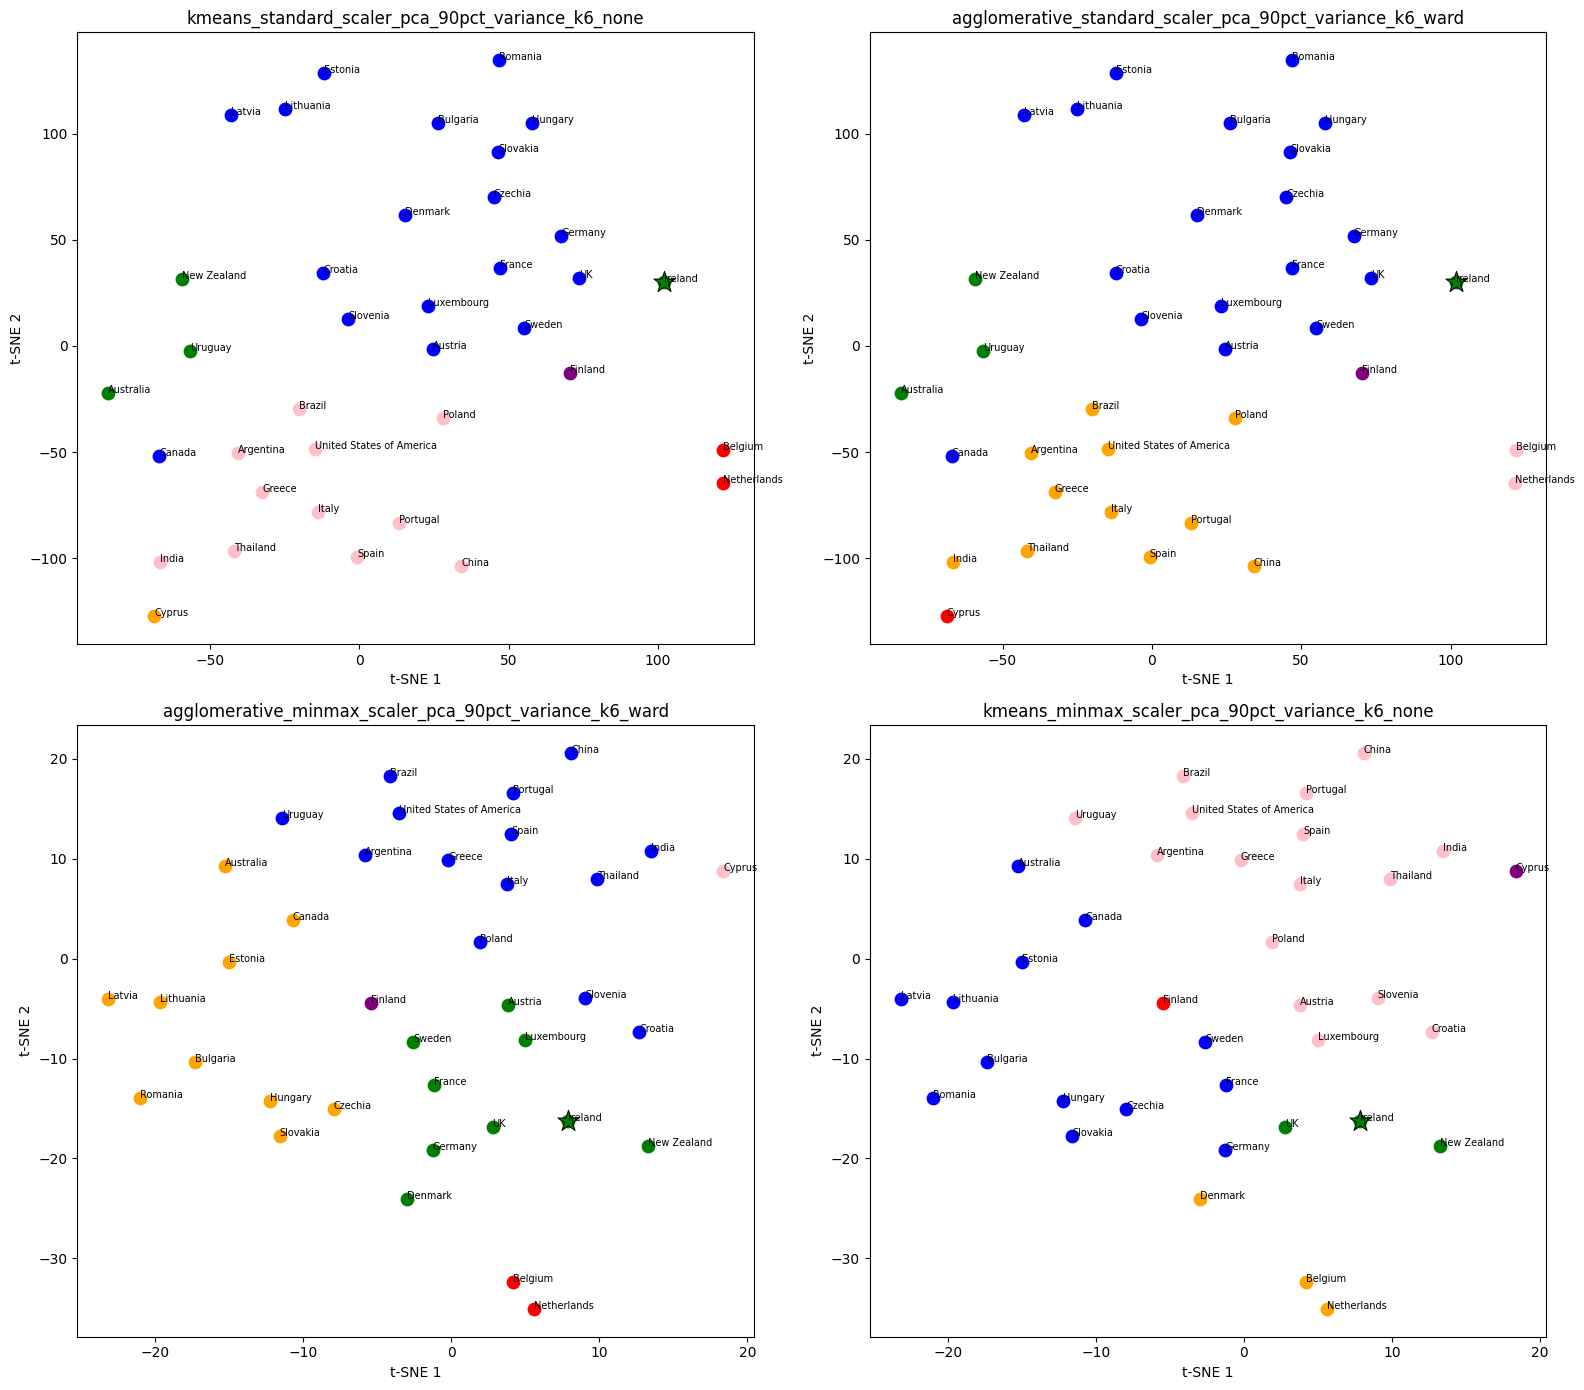

In [204]:
# Run t-SNE plots for the top 4 shortlisted models
plot_tsne_for_top_models(top_run_ids=top4_run_ids, run_artifacts=run_artifacts, df=df)

The t-SNE plots show that the shortlisted models are not identical, but they do show some recurring structure.

Most importantly, **Ireland is repeatedly associated with a small set of developed, temperate, livestock/pasture-relevant agricultural countries**, especially the UK and New Zealand. Depending on the scaler and clustering algorithm, the Ireland group either stays very focused or expands into a broader European comparison group.

### Dendrograms for shortlisted agglomerative models

In [215]:
def plot_dendrograms_for_top_agglomerative_models(top_run_ids, run_artifacts, df):
    """
    Plot dendrograms for shortlisted agglomerative clustering models

    Parameters:
        top_run_ids = list of shortlisted run_id values
        run_artifacts = dictionary of model artifacts from the original grid search
        df = original country-level dataset containing country_name
    """

    # keep only shortlisted runs that used Agglomerative clustering
    agg_run_ids = [run_id for run_id in top_run_ids if run_artifacts[run_id]["model_name"] == "agglomerative"]

    # create subplot grid
    fig, axes = plt.subplots(nrows=1, ncols=len(agg_run_ids), figsize=(10*len(agg_run_ids), 7))

    # define the colour that will always represent Ireland's cluster
    ireland_cluster_colour = "green"
    # define colours for all other clusters (deliberately not green so Ireland's cluster stands out)
    other_cluster_colours = ["blue", "orange", "red", "purple", "pink"]

    # Loop through each agglomerative run and subplot axis
    for ax, run_id in zip(axes, agg_run_ids):
        run = run_artifacts[run_id]       # retrieve the stored model run
        X_model = run["X_model"]          # get the data matrix used by the clustering model
        labels = run["labels"]        # get the stored cluster labels
        linkage_method = run["linkage"]   # get the linkage method

        # get the selected number of clusters
        k = run["k"]

        # calculate the hierarchical linkage matrix using scipy (ward linkage is based on Euclidean distance)
        Z = linkage(X_model, method=linkage_method, metric="euclidean")

        # calculate the approximate height where the dendrogram should be cut to produce k clusters
        cut_height = Z[-(k - 1), 2]

        # draw the dendrogram
        dendrogram(Z, labels=list(df["country_plot_label"]), leaf_rotation=90, leaf_font_size=8, ax=ax)

        # draw the horizontal cut line showing where the tree is cut into k clusters
        ax.axhline(y=cut_height, linestyle="--", color="black", label=f"k={k} cut")

        # find Ireland's row index in the original dataframe
        ireland_index = df.index[df["country_name"] == "Ireland"][0]
    
        # find which cluster Ireland belongs to in this model
        ireland_cluster_label = labels[ireland_index]
    
        # colour the x-axis labels green for countries in Ireland's cluster
        for tick_label in ax.get_xmajorticklabels():
    
            # get the label shown on the dendrogram
            country_plot_label = tick_label.get_text()
    
            # find the corresponding row in df
            country_index = df.index[df["country_plot_label"] == country_plot_label][0]
    
            # if this country is in the same cluster as Ireland, colour its label green and make it bold
            if labels[country_index] == ireland_cluster_label:
                tick_label.set_color("green")
                tick_label.set_fontweight("bold")

        ax.set_title(run_id)
        ax.set_ylabel("Distance")

        # Add legend for the cut line.
        ax.legend()

    plt.tight_layout()
    plt.show()

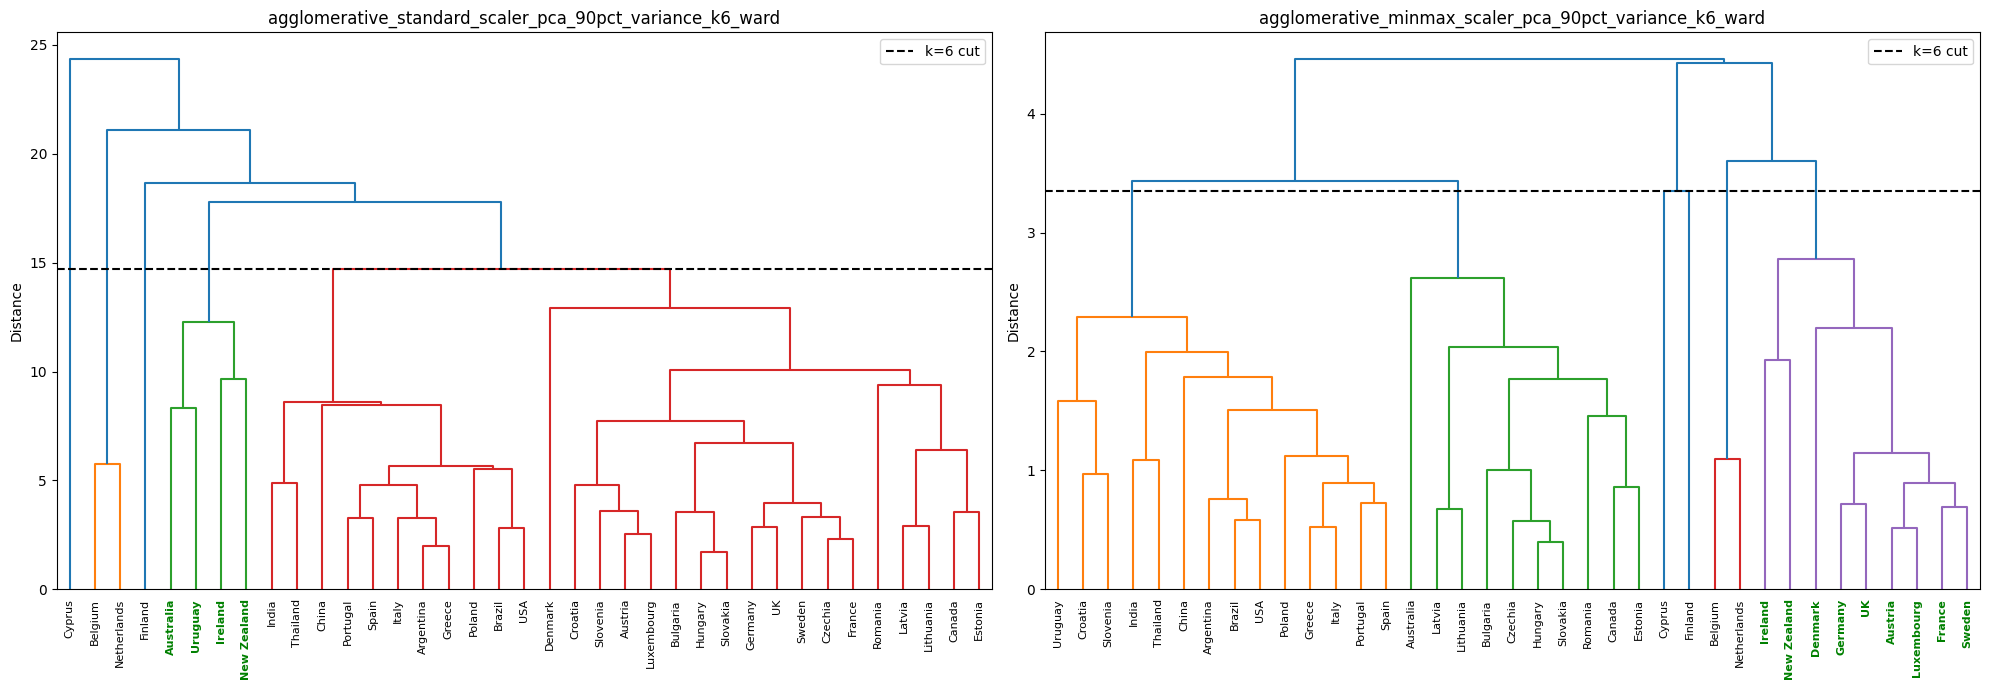

In [217]:
# Plot dendrograms for shortlisted agglomerative models
plot_dendrograms_for_top_agglomerative_models(top_run_ids=top4_run_ids, run_artifacts=run_artifacts, df=df)

Rather than treating a single clustering algorithm as definitive, we focuse the final interpretation on countries that were repeatedly grouped with Ireland across the four shortlisted models. This is appropriate because the shortlisted models have similar validation performance but differ in the size of Ireland's cluster. Countries consistently appearing in Ireland's cluster are interpreted as core comparators, while countries appearing only in one model were treated as model-specific or broader contextual comparators.